<p style="font-size:24px">Σύστημα Διαχείρισης & Ανάλυσης Μετεωρολογικών Δεδομένων</p>

<p style="font-size:18px">Τουτουντζάκης Χαρίλαος 2026</p>
<p style="font-size:18px">ΠΜΣ Εφαρμοσμένα Μαθηματικά & Μηχανική Μάθηση</p>
<p style="font-size:18px">Θέματα Προγραμματισμού Η/Υ</p>

---




---
## Βήμα 0 -- Download, Εισαγωγή Βιβλιοθηκών & Κεντρικό Λεξικό Αποθήκευσης


In [ ]:
!pip install pandas numpy matplotlib



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from datetime import datetime

# Ρύθμιση για εμφάνιση γραφημάτων inline στο Notebook
%matplotlib inline


print('✅ Βιβλιοθήκες φορτώθηκαν επιτυχώς!')


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\xaris\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


✅ Βιβλιοθήκες φορτώθηκαν επιτυχώς!


# 1ο Στάδιο — Βασική Διαχείριση Δεδομένων

---

## Βήμα 1ο -- Δομή Δεδομένων & Υλοποίηση Συναρτήσεων με Διαχείριση Σφαλμάτων

In [ ]:

# ────────────────────────────────────────────────
# Κεντρική δομή δεδομένων: λεξικό Python
# Κάθε κλειδί είναι μοναδικό (π.χ. 'ATH_2024-05-01')
# και αντιστοιχεί σε ένα εσωτερικό λεξικό με τα πεδία μέτρησης.
# ────────────────────────────────────────────────
weather_data = {}



# ════════════════════════════════════════════════


def add_measurement(station_name, date_str, temp, humidity, wind_speed, condition):
    """
    Προσθήκη νέας μέτρησης στο weather_data με ελέγχους εγκυρότητας.
    
    Παράμετροι:
        station_name : str  — Όνομα μετεωρολογικού σταθμού
        date_str     : str  — Ημερομηνία σε μορφή 'YYYY-MM-DD'
        temp         : float — Θερμοκρασία σε °C (έγκυρο: -50 έως 60)
        humidity     : float — Υγρασία σε % (έγκυρο: 0 έως 100)
        wind_speed   : float — Ταχύτητα ανέμου σε km/h (≥ 0)
        condition    : str  — Περιγραφή καιρικών συνθηκών
    """
    try:
        # Επαλήθευση μορφής ημερομηνίας — αν δεν ταιριάζει, ValueError
        datetime.strptime(date_str, '%Y-%m-%d')

        # Λογικοί έλεγχοι τιμών
        if not (-50 <= temp <= 60):
            raise ValueError(f'Παράλογη θερμοκρασία: {temp}°C')
        if not (0 <= humidity <= 100):
            raise ValueError(f'Μη έγκυρη υγρασία: {humidity}%')
        if wind_speed < 0:
            raise ValueError('Η ταχύτητα ανέμου δεν μπορεί να είναι αρνητική.')

        # Δημιουργία μοναδικού κλειδιού: πρώτα 3 γράμματα σταθμού + ημερομηνία
        station_id = station_name[:3].upper()
        unique_key = f'{station_id}_{date_str}'

        # Αποτροπή διπλοτύπων
        if unique_key in weather_data:
            raise KeyError(f"Η εγγραφή '{unique_key}' υπάρχει ήδη.")

        # Αποθήκευση στο κεντρικό λεξικό
        weather_data[unique_key] = {
            'Σταθμός': station_name,
            'Ημερομηνία': date_str,
            'Θερμοκρασία (°C)': temp,
            'Υγρασία (%)': humidity,
            'Ταχύτητα ανέμου (km/h)': wind_speed,
            'Καιρικές συνθήκες': condition
        }
        print(f'✅ Καταχωρήθηκε: {unique_key}')

    except ValueError as ve:
        print(f'❌ Σφάλμα Τιμών: {ve}')
    except KeyError as ke:
        print(f'❌ Σφάλμα Διπλοτύπου: {ke}')
    except Exception as e:
        print(f'❌ Απρόσμενο σφάλμα: {e}')


# ════════════════════════════════════════════════


def delete_measurement(unique_id):
    """Διαγραφή μέτρησης βάσει ID."""
    try:
        if unique_id not in weather_data:
            raise KeyError(f"Το αναγνωριστικό '{unique_id}' δεν βρέθηκε.")
        
        del weather_data[unique_id]
        print(f"🗑️ Η εγγραφή '{unique_id}' διαγράφηκε.")
    except KeyError as ke:
        print(f"❌ Σφάλμα: {ke}")

# # ════════════════════════════════════════════════



def search_measurements(station=None, start_date=None, end_date=None):
    """Αναζήτηση με φίλτρα."""
    try:
        results = {}
        for k, v in weather_data.items():
            # Φίλτρο σταθμού
            st_match = (station is None) or (v["Σταθμός"].lower() == station.lower())
            
            # Φίλτρο ημερομηνιών
            dt_match = True
            if start_date and end_date:
                dt_match = start_date <= v["Ημερομηνία"] <= end_date
            
            if st_match and dt_match:
                results[k] = v
        
        if not results:
            print("ℹ️ Δεν βρέθηκαν αποτελέσματα.")
        return results
    except Exception as e:
        print(f"❌ Σφάλμα κατά την αναζήτηση: {e}")
        return {}


# ════════════════════════════════════════════════

def display_all():
    """
    Μετατρέπει το weather_data σε pandas DataFrame για εύκολη επεξεργασία.
    Επιστρέφει None αν το λεξικό είναι άδειο.
    """
    if not weather_data:
        print('Το λεξικό είναι άδειο.')
        return None
    return pd.DataFrame.from_dict(weather_data, orient='index')


print('✅ Βασικές συναρτήσεις ορίστηκαν.')

✅ Βασικές συναρτήσεις ορίστηκαν.


## Βήμα 2ο -- Στατιστική Ανάλυση & Μενού

In [ ]:
def run_statistics():
    """Ανάλυση δεδομένων με pandas."""
    try:
        if not weather_data:
            print("Δεν υπάρχουν δεδομένα για στατιστική ανάλυση.")
            return

        df = display_all()
        df['Ημερομηνία'] = pd.to_datetime(df['Ημερομηνία'])
        
        print("\n📊 --- Στατιστικά Θερμοκρασίας ανά Σταθμό ---")
        print(df.groupby('Σταθμός')['Θερμοκρασία (°C)'].agg(['mean', 'max', 'min']))
        
        print("\n☁️ --- Κατανομή Καιρικών Συνθηκών ---")
        print(df['Καιρικές συνθήκες'].value_counts())
        
        print("\n💧 --- Μήνας με τη μεγαλύτερη μέση υγρασία ---")
        df['Μήνας'] = df['Ημερομηνία'].dt.month_name()
        avg_hum = df.groupby('Μήνας')['Υγρασία (%)'].mean()
        print(f"Πρωταθλητής υγρασίας: {avg_hum.idxmax()} με {avg_hum.max():.1f}%")
        
    except Exception as e:
        print(f"❌ Σφάλμα ανάλυσης: {e}")


# ════════════════════════════════════════════════


def main():
    """Το κεντρικό μενού αλληλεπίδρασης."""
    while True:
        print("\n=== METEO MANAGER v1.0 ===")
        print("1. Προσθήκη | 2. Διαγραφή | 3. Αναζήτηση | 4. Προβολή Όλων | 5. Στατιστικά | 6. Αποθήκευση | 7. Έξοδος")         
        cmd = input("Επιλογή: ")
        
        if cmd == '1':
            name = input("Σταθμός: ")
            date = input("Ημερομηνία (YYYY-MM-DD): ")
            try:
                t = float(input("Θερμοκρασία (°C): "))
                h = float(input("Υγρασία (%): "))
                w = float(input("Ταχύτητα Ανέμου (km/h): "))
                c = input("Καιρικές συνθήκες: ")
                add_measurement(name, date, t, h, w, c)
            except ValueError:
                print("❌ Σφάλμα: Δώστε αριθμούς για θερμοκρασία/υγρασία/άνεμο.")
        
        elif cmd == '2':
            uid = input("Δώστε το ID (π.χ. ATH_2024-03-15): ")
            delete_measurement(uid)
            
        elif cmd == '3':
            st = input("Σταθμός (Enter για όλους): ") or None
            sd = input("Από (YYYY-MM-DD) ή Enter: ") or None
            ed = input("Έως (YYYY-MM-DD) ή Enter: ") or None
            res = search_measurements(st, sd, ed)
            if res: print(pd.DataFrame.from_dict(res, orient='index'))
            
        elif cmd == '4':
            df = display_all()
            if df is not None: print(df)
            
        elif cmd == '5':
            run_statistics()
         
        elif cmd == '6':
            print("Αποθήκευση σε: 1. JSON  2. CSV  3. Και τα δύο")
            choice = input("Επιλογή: ")
            if choice == '1':
                save_to_json()
            elif choice == '2':
                save_to_csv()
            elif choice == '3':
                save_to_json()
                save_to_csv()
            else:
                print("Λάθος επιλογή.")

        elif cmd == '7':
            print("Τερματισμός... Καλή συνέχεια!")
            break


# 2ο Στάδιο — Αποθήκευση, Οπτικοποίηση & Ανάλυση

---

## Βήμα 1 -- Αποθήκευση & Φόρτωση Δεδομένων (JSON & CSV)

Ένα πρόγραμμα που χάνει τα δεδομένα του κάθε φορά που τερματίζει δεν είναι χρήσιμο.
Υλοποιούμε **persistence** (μόνιμη αποθήκευση) μέσω δύο μορφών:

- **JSON**: Ιδανικό για ιεραρχικά/λεξικά δεδομένα — διαβάζεται από ανθρώπους,
  ευέλικτο, υποστηρίζει nested δομές.
- **CSV**: Ιδανικό για πίνακες — συμβατό με Excel, pandas, R κ.ά.

Και οι δύο συναρτήσεις χρησιμοποιούν `try/except` για να χειριστούν
σφάλματα αρχείων (π.χ. αρχείο δεν βρέθηκε, κατεστραμμένο JSON, κ.λπ.).

In [ ]:
# ════════════════════════════════════════════════
# ΑΠΟΘΗΚΕΥΣΗ & ΦΟΡΤΩΣΗ — JSON
# ════════════════════════════════════════════════

# Ορισμός σταθερού ονόματος αρχείου JSON
JSON_FILE = 'weather_data.json'


def save_to_json(filepath=JSON_FILE):
    """
    Αποθηκεύει το weather_data λεξικό σε αρχείο JSON.
    
    Χρησιμοποιεί indent=2 για αναγνώσιμη μορφοποίηση
    και ensure_ascii=False για σωστή αποθήκευση ελληνικών χαρακτήρων.
    """
    try:
        with open(filepath, 'w', encoding='utf-8') as f:
            json.dump(weather_data, f, ensure_ascii=False, indent=2)
        print(f'💾 Δεδομένα αποθηκεύτηκαν στο: {filepath}')
    except PermissionError:
        # Συμβαίνει αν δεν έχουμε δικαιώματα εγγραφής στον φάκελο
        print(f'❌ Δεν υπάρχουν δικαιώματα εγγραφής για: {filepath}')
    except Exception as e:
        print(f'❌ Αποτυχία αποθήκευσης JSON: {e}')


# ════════════════════════════════════════════════


def load_from_json(filepath=JSON_FILE):
    """
    Φορτώνει δεδομένα από αρχείο JSON στο weather_data.
    
    Ελέγχει πρώτα αν το αρχείο υπάρχει (os.path.exists).
    Αν το αρχείο είναι κατεστραμμένο (invalid JSON), πιάνει το JSONDecodeError.
    Χρησιμοποιεί global για να τροποποιήσει το κεντρικό λεξικό.
    """
    global weather_data  # Απαιτείται για να αντικαταστήσουμε το εξωτερικό λεξικό
    try:
        # Έλεγχος ύπαρξης αρχείου πριν προσπαθήσουμε να το ανοίξουμε
        if not os.path.exists(filepath):
            print(f'ℹ️  Το αρχείο "{filepath}" δεν βρέθηκε. Ξεκινάμε με κενό σύστημα.')
            return

        with open(filepath, 'r', encoding='utf-8') as f:
            loaded = json.load(f)  # Αποκωδικοποίηση JSON → Python dict

        weather_data = loaded
        print(f'📂 Φορτώθηκαν {len(weather_data)} εγγραφές από: {filepath}')

    except json.JSONDecodeError as je:
        # Το αρχείο υπάρχει αλλά δεν είναι έγκυρο JSON
        print(f'❌ Κατεστραμμένο αρχείο JSON: {je}')
    except Exception as e:
        print(f'❌ Αποτυχία φόρτωσης JSON: {e}')


print('✅ Συναρτήσεις JSON ορίστηκαν.')

✅ Συναρτήσεις JSON ορίστηκαν.


In [ ]:
# ════════════════════════════════════════════════
# ΑΠΟΘΗΚΕΥΣΗ & ΦΟΡΤΩΣΗ — CSV
# ════════════════════════════════════════════════

CSV_FILE = 'weather_data.csv'


def save_to_csv(filepath=CSV_FILE):
    """
    Αποθηκεύει τα δεδομένα σε CSV μέσω pandas DataFrame.
    
    Το index=True κρατάει το μοναδικό κλειδί (ATH_2024-05-01) ως πρώτη στήλη.
    encoding='utf-8-sig' εξασφαλίζει σωστή εμφάνιση ελληνικών στο Excel.
    """
    try:
        if not weather_data:
            print('⚠️  Δεν υπάρχουν δεδομένα για αποθήκευση.')
            return

        df = pd.DataFrame.from_dict(weather_data, orient='index')
        # index_label δίνει όνομα στη στήλη του index
        df.to_csv(filepath, index=True, index_label='ID', encoding='utf-8-sig')
        print(f'💾 CSV αποθηκεύτηκε: {filepath} ({len(df)} γραμμές)')

    except PermissionError:
        print(f'❌ Δεν υπάρχουν δικαιώματα εγγραφής για: {filepath}')
    except Exception as e:
        print(f'❌ Αποτυχία αποθήκευσης CSV: {e}')


# ════════════════════════════════════════════════



def load_from_csv(filepath=CSV_FILE):
    """
    Φορτώνει δεδομένα από CSV και τα μετατρέπει ξανά σε λεξικό.
    
    index_col='ID' ορίζει το μοναδικό κλειδί ως index του DataFrame.
    to_dict(orient='index') μετατρέπει κάθε γραμμή σε εσωτερικό λεξικό.
    """
    global weather_data
    try:
        if not os.path.exists(filepath):
            print(f'ℹ️  Το αρχείο "{filepath}" δεν βρέθηκε.')
            return

        df = pd.read_csv(filepath, index_col='ID', encoding='utf-8-sig')

        # Μετατροπή κάθε γραμμής του DataFrame σε Python dict
        weather_data = df.to_dict(orient='index')
        print(f'📂 Φορτώθηκαν {len(weather_data)} εγγραφές από CSV: {filepath}')

    except pd.errors.EmptyDataError:
        print('⚠️  Το CSV αρχείο είναι κενό.')
    except Exception as e:
        print(f'❌ Αποτυχία φόρτωσης CSV: {e}')


print('✅ Συναρτήσεις CSV ορίστηκαν.')

✅ Συναρτήσεις CSV ορίστηκαν.


In [ ]:
# ════════════════════════════════════════════════
# ΑΥΤΟΜΑΤΗ ΦΟΡΤΩΣΗ ΚΑΤΑ ΤΗΝ ΕΚΚΙΝΗΣΗ
# ════════════════════════════════════════════════
# Αυτό το κελί προσομοιώνει την εκκίνηση του προγράμματος.
# Ελέγχει αν υπάρχει αρχείο JSON και αν ναι, το φορτώνει αυτόματα.
# Προτιμάμε JSON γιατί διατηρεί καλύτερα τους τύπους δεδομένων (int/float).

def auto_load():
    """
    Αυτόματη φόρτωση κατά την εκκίνηση.
    Προτεραιότητα: JSON > CSV > κενό σύστημα.
    """
    if os.path.exists(JSON_FILE):
        print('🔄 Βρέθηκε αρχείο JSON — αυτόματη φόρτωση...')
        load_from_json()
    elif os.path.exists(CSV_FILE):
        print('🔄 Βρέθηκε αρχείο CSV — αυτόματη φόρτωση...')
        load_from_csv()
    else:
        print('ℹ️  Δεν βρέθηκε αποθηκευμένο αρχείο. Ξεκινάμε με κενό σύστημα.')

# Εκτέλεση αυτόματης φόρτωσης
auto_load()

🔄 Βρέθηκε αρχείο JSON — αυτόματη φόρτωση...
📂 Φορτώθηκαν 23 εγγραφές από: weather_data.json


---
## Βήμα 2 — Δοκιμαστικά Δεδομένα

Εισάγουμε ένα αντιπροσωπευτικό σύνολο δεδομένων από **3 σταθμούς**
και **πολλαπλές ημερομηνίες** ώστε να μπορούμε να δούμε ουσιαστικά
αποτελέσματα στα γραφήματα και τις αναλύσεις που ακολουθούν.

In [ ]:
# Προσθήκη δοκιμαστικών μετρήσεων μόνο αν το σύστημα είναι κενό
# (δεν θέλουμε να ξαναπροσθέσουμε αν φορτώσαμε ήδη δεδομένα)

if not weather_data:
    print('📥 Εισαγωγή δοκιμαστικών δεδομένων...\n')

    # ── Σταθμός: Αθήνα ──
    add_measurement('Αθήνα',       '2024-01-10', 8.5,  72, 15, 'Συννεφιά')
    add_measurement('Αθήνα',       '2024-02-14', 11.2, 65, 20, 'Ηλιοφάνεια')
    add_measurement('Αθήνα',       '2024-03-20', 16.0, 58, 10, 'Ηλιοφάνεια')
    add_measurement('Αθήνα',       '2024-04-05', 19.5, 50, 25, 'Ηλιοφάνεια')
    add_measurement('Αθήνα',       '2024-05-18', 26.3, 40, 18, 'Ηλιοφάνεια')
    add_measurement('Αθήνα',       '2024-06-22', 33.1, 35, 12, 'Καύσωνας')
    add_measurement('Αθήνα',       '2024-07-15', 38.0, 28, 8,  'Καύσωνας')  # Υψηλή τιμή
    add_measurement('Αθήνα',       '2024-08-10', 36.4, 30, 10, 'Καύσωνας')
    add_measurement('Αθήνα',       '2024-09-25', 27.0, 48, 20, 'Αίθριος')
    add_measurement('Αθήνα',       '2024-10-08', 20.1, 60, 22, 'Συννεφιά')
    add_measurement('Αθήνα',       '2024-11-12', 13.0, 75, 30, 'Βροχή')
    add_measurement('Αθήνα',       '2024-12-20', 7.5,  80, 35, 'Βροχή')

    # ── Σταθμός: Θεσσαλονίκη ──
    add_measurement('Θεσσαλονίκη', '2024-01-10', 3.2,  78, 20, 'Χιόνι')
    add_measurement('Θεσσαλονίκη', '2024-03-20', 12.5, 62, 18, 'Συννεφιά')
    add_measurement('Θεσσαλονίκη', '2024-06-22', 29.8, 45, 15, 'Ηλιοφάνεια')
    add_measurement('Θεσσαλονίκη', '2024-07-15', 35.5, 32, 10, 'Καύσωνας')
    add_measurement('Θεσσαλονίκη', '2024-09-25', 22.4, 55, 25, 'Αίθριος')
    add_measurement('Θεσσαλονίκη', '2024-11-12', 9.1,  82, 28, 'Βροχή')

    # ── Σταθμός: Ηράκλειο ──
    add_measurement('Ηράκλειο',    '2024-01-10', 13.0, 68, 22, 'Αίθριος')
    add_measurement('Ηράκλειο',    '2024-04-05', 21.0, 55, 20, 'Ηλιοφάνεια')
    add_measurement('Ηράκλειο',    '2024-07-15', 30.5, 60, 15, 'Ηλιοφάνεια')  # outlier υγρασίας για νότο
    add_measurement('Ηράκλειο',    '2024-10-08', 24.0, 65, 18, 'Αίθριος')
    add_measurement('Ηράκλειο',    '2024-12-20', 14.5, 72, 25, 'Βροχή')

    print('\n✅ Δοκιμαστικά δεδομένα καταχωρήθηκαν!')
else:
    print(f'ℹ️  Υπάρχουν ήδη {len(weather_data)} εγγραφές — παράλειψη εισαγωγής.')

# Προβολή όλων των δεδομένων ως DataFrame
df_all = display_all()
df_all

ℹ️  Υπάρχουν ήδη 23 εγγραφές — παράλειψη εισαγωγής.


,Σταθμός,Ημερομηνία,Θερμοκρασία (°C),Υγρασία (%),Ταχύτητα ανέμου (km/h),Καιρικές συνθήκες
ΑΘΉ_2024-01-10,Αθήνα,2024-01-10,8.5,72,15,Συννεφιά
ΑΘΉ_2024-02-14,Αθήνα,2024-02-14,11.2,65,20,Ηλιοφάνεια
ΑΘΉ_2024-03-20,Αθήνα,2024-03-20,16.0,58,10,Ηλιοφάνεια
ΑΘΉ_2024-04-05,Αθήνα,2024-04-05,19.5,50,25,Ηλιοφάνεια
ΑΘΉ_2024-05-18,Αθήνα,2024-05-18,26.3,40,18,Ηλιοφάνεια
ΑΘΉ_2024-06-22,Αθήνα,2024-06-22,33.1,35,12,Καύσωνας
ΑΘΉ_2024-07-15,Αθήνα,2024-07-15,38.0,28,8,Καύσωνας
ΑΘΉ_2024-08-10,Αθήνα,2024-08-10,36.4,30,10,Καύσωνας
ΑΘΉ_2024-09-25,Αθήνα,2024-09-25,27.0,48,20,Αίθριος
ΑΘΉ_2024-10-08,Αθήνα,2024-10-08,20.1,60,22,Συννεφιά


In [ ]:
# Αποθήκευση δεδομένων και στις δύο μορφές για επίδειξη
save_to_json()
save_to_csv()

💾 Δεδομένα αποθηκεύτηκαν στο: weather_data.json
💾 CSV αποθηκεύτηκε: weather_data.csv (23 γραμμές)


---
## Βήμα 3 — Γραφήματα (matplotlib)

Τα γραφήματα είναι το κυριότερο εργαλείο **Exploratory Data Analysis (EDA)**.
Υλοποιούμε τρία είδη:

| Γράφημα | Ερώτημα που απαντά |
|---|---|
| **Bar Chart** | Πόσο συχνά εμφανίζεται κάθε καιρικό φαινόμενο; |
| **Line Chart** | Πώς εξελίχθηκε η θερμοκρασία ενός σταθμού μέσα στο χρόνο; |
| **Scatter Plot** | Υπάρχει συσχέτιση θερμοκρασίας–υγρασίας; |

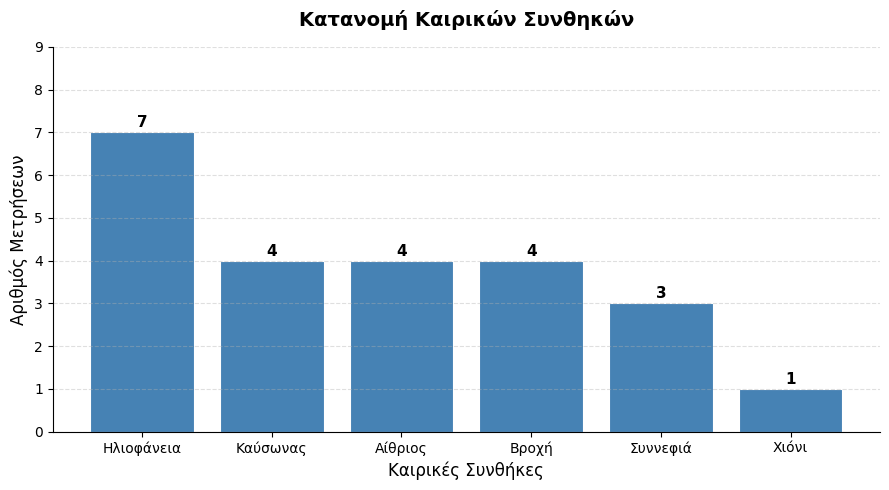

📊 Bar chart εμφανίστηκε.


In [ ]:
# ════════════════════════════════════════════════
# ΓΡΑΦΗΜΑ 1: BAR CHART — Κατανομή Καιρικών Συνθηκών
# ════════════════════════════════════════════════
# Αριθμεί πόσες φορές εμφανίστηκε κάθε καιρικό φαινόμενο.
# Η value_counts() μετράει τις επαναλήψεις κάθε μοναδικής τιμής.

def plot_weather_conditions(df):
    """
    Bar chart κατανομής καιρικών συνθηκών.
    
    Παράμετρος:
        df : pandas DataFrame με στήλη 'Καιρικές συνθήκες'
    """
    # Μέτρηση εμφανίσεων κάθε συνθήκης
    condition_counts = df['Καιρικές συνθήκες'].value_counts()

    fig, ax = plt.subplots(figsize=(9, 5))

    # Δημιουργία bar chart — color='steelblue' για ομοιόμορφο χρώμα
    bars = ax.bar(condition_counts.index, condition_counts.values,
                  color='steelblue', edgecolor='white', linewidth=0.8)

    # Εμφάνιση αριθμητικής τιμής πάνω από κάθε μπάρα
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.05,
                str(int(height)), ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_title('Κατανομή Καιρικών Συνθηκών', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Καιρικές Συνθήκες', fontsize=12)
    ax.set_ylabel('Αριθμός Μετρήσεων', fontsize=12)
    ax.set_ylim(0, condition_counts.max() + 2)  # Χώρος για labels
    ax.grid(axis='y', alpha=0.4, linestyle='--')  # Οριζόντιο πλέγμα για ευανάγνωστο
    ax.spines[['top', 'right']].set_visible(False)  # Αφαίρεση περιττών αξόνων

    plt.tight_layout()
    plt.show()
    print('📊 Bar chart εμφανίστηκε.')


# Κλήση της συνάρτησης
plot_weather_conditions(df_all)

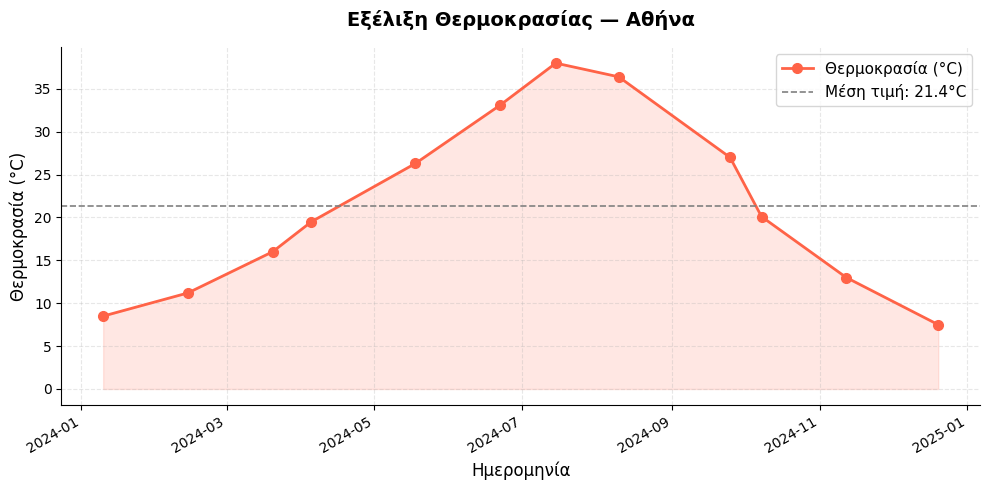

📈 Line chart για "Αθήνα" εμφανίστηκε.


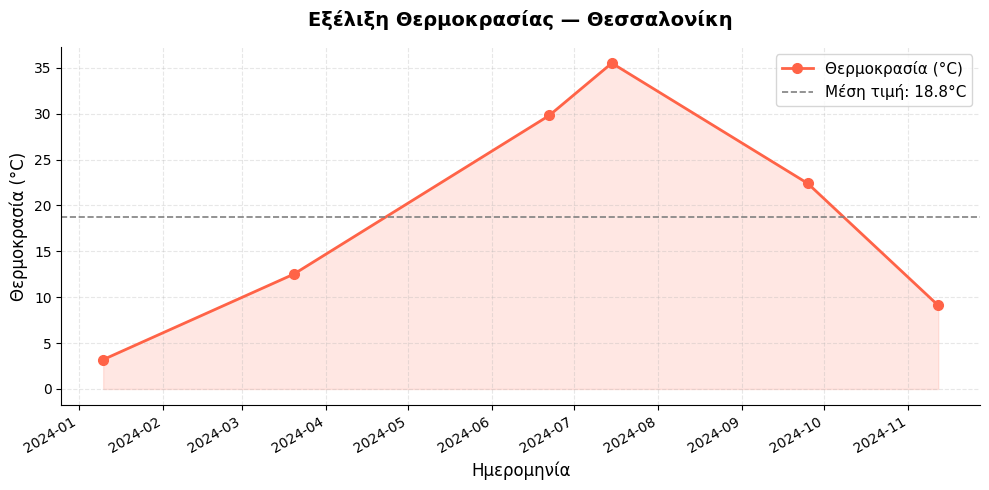

📈 Line chart για "Θεσσαλονίκη" εμφανίστηκε.


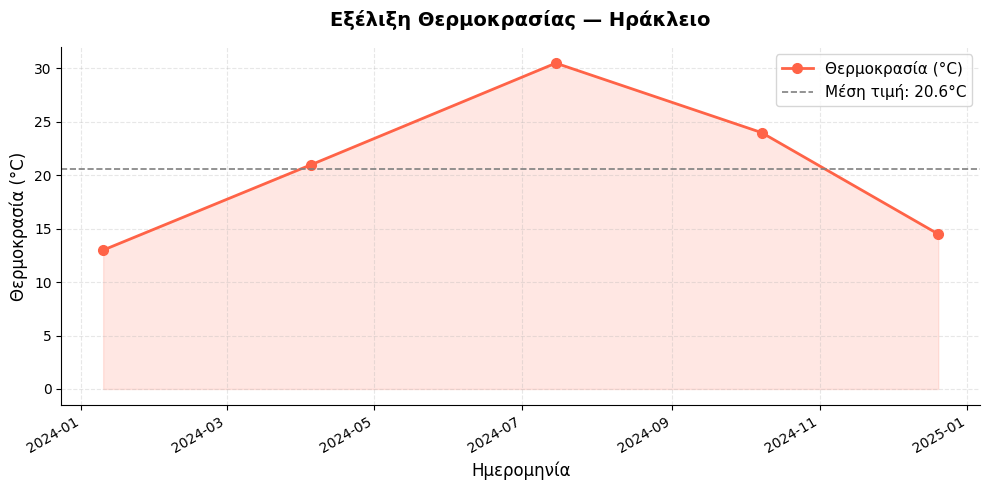

📈 Line chart για "Ηράκλειο" εμφανίστηκε.


In [ ]:
# ════════════════════════════════════════════════
# ΓΡΑΦΗΜΑ 2: LINE CHART — Εξέλιξη Θερμοκρασίας στον Χρόνο
# ════════════════════════════════════════════════
# Εμφανίζει πώς μεταβάλλεται η θερμοκρασία ενός σταθμού
# μέσα στους μήνες. Χρειαζόμαστε ταξινόμηση κατά ημερομηνία
# για να εμφανιστεί σωστά η χρονοσειρά.

def plot_temperature_over_time(df, station_name):
    """
    Line chart θερμοκρασίας για συγκεκριμένο σταθμό.
    
    Παράμετροι:
        df           : pandas DataFrame
        station_name : str — Όνομα σταθμού (π.χ. 'Αθήνα')
    """
    # Φιλτράρισμα μόνο του επιλεγμένου σταθμού
    df_station = df[df['Σταθμός'] == station_name].copy()

    if df_station.empty:
        print(f'⚠️  Δεν βρέθηκαν δεδομένα για τον σταθμό: {station_name}')
        return

    # Μετατροπή σε datetime και ταξινόμηση — απαραίτητο για σωστή χρονοσειρά
    df_station['Ημερομηνία'] = pd.to_datetime(df_station['Ημερομηνία'])
    df_station = df_station.sort_values('Ημερομηνία')

    fig, ax = plt.subplots(figsize=(10, 5))

    # Κύρια γραμμή θερμοκρασίας
    ax.plot(df_station['Ημερομηνία'], df_station['Θερμοκρασία (°C)'],
            marker='o',        # Σημεία σε κάθε μέτρηση
            linewidth=2,
            color='tomato',
            markersize=7,
            label='Θερμοκρασία (°C)')

    # Γέμισμα κάτω από τη γραμμή για οπτική έμφαση
    ax.fill_between(df_station['Ημερομηνία'], df_station['Θερμοκρασία (°C)'],
                    alpha=0.15, color='tomato')

    # Οριζόντια γραμμή μέσης τιμής
    mean_temp = df_station['Θερμοκρασία (°C)'].mean()
    ax.axhline(mean_temp, color='gray', linestyle='--', linewidth=1.2,
               label=f'Μέση τιμή: {mean_temp:.1f}°C')

    ax.set_title(f'Εξέλιξη Θερμοκρασίας — {station_name}', fontsize=14,
                 fontweight='bold', pad=15)
    ax.set_xlabel('Ημερομηνία', fontsize=12)
    ax.set_ylabel('Θερμοκρασία (°C)', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

    # Περιστροφή ετικετών ημερομηνίας για αναγνωσιμότητα
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
    print(f'📈 Line chart για "{station_name}" εμφανίστηκε.')


# Εμφάνιση για την Αθήνα, Θεσσαλονίκη και Ηράκλειο (12 μετρήσεις — ιδανικό για χρονοσειρά)
plot_temperature_over_time(df_all, 'Αθήνα')
plot_temperature_over_time(df_all, 'Θεσσαλονίκη')
plot_temperature_over_time(df_all, 'Ηράκλειο')

In [ ]:
# ════════════════════════════════════════════════
# ΓΡΑΦΗΜΑ 3: SCATTER PLOT — Θερμοκρασία έναντι Υγρασίας
# ════════════════════════════════════════════════
# Ο scatter plot αποκαλύπτει αν υπάρχει ΣΥΣΧΕΤΙΣΗ (correlation)
# μεταξύ θερμοκρασίας και υγρασίας.
# Αναμένουμε αρνητική συσχέτιση: όσο ανεβαίνει η θερμοκρασία,
# τόσο πέφτει η σχετική υγρασία.
# Κάθε σταθμός έχει διαφορετικό χρώμα για σύγκριση.

def plot_temp_vs_humidity(df):
    """
    Scatter plot θερμοκρασίας vs υγρασίας, με χρωματισμό ανά σταθμό.
    
    Παράμετρος:
        df : pandas DataFrame με όλες τις μετρήσεις
    """
    fig, ax = plt.subplots(figsize=(9, 6))

    # Παλέτα χρωμάτων για τους σταθμούς
    palette = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
    stations = df['Σταθμός'].unique()

    # Ζωγραφίζουμε κάθε σταθμό ξεχωριστά για legend
    for i, station in enumerate(stations):
        subset = df[df['Σταθμός'] == station]
        ax.scatter(subset['Θερμοκρασία (°C)'], subset['Υγρασία (%)'],
                   label=station,
                   color=palette[i % len(palette)],
                   s=80,           # Μέγεθος σημείων
                   alpha=0.8,
                   edgecolors='white',
                   linewidth=0.8)

    # Γραμμή τάσης (trend line) με numpy polyfit (1ου βαθμού = γραμμική)
    # Δείχνει την γενική κατεύθυνση της σχέσης θερμοκρασίας-υγρασίας
    x = df['Θερμοκρασία (°C)'].values
    y = df['Υγρασία (%)'].values
    coeffs = np.polyfit(x, y, 1)       # Υπολογισμός συντελεστών ευθείας y=ax+b
    trend_x = np.linspace(x.min(), x.max(), 100)
    trend_y = np.polyval(coeffs, trend_x)  # Εφαρμογή πολυωνύμου
    ax.plot(trend_x, trend_y, 'k--', linewidth=1.5, alpha=0.6, label='Γραμμή τάσης')

    # Υπολογισμός & εμφάνιση συντελεστή Pearson r
    corr = np.corrcoef(x, y)[0, 1]  # [0,1] = τιμή εκτός διαγωνίου
    ax.text(0.05, 0.92, f'r = {corr:.2f}', transform=ax.transAxes,
            fontsize=12, color='black',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

    ax.set_title('Θερμοκρασία vs Υγρασία (ανά Σταθμό)', fontsize=14,
                 fontweight='bold', pad=15)
    ax.set_xlabel('Θερμοκρασία (°C)', fontsize=12)
    ax.set_ylabel('Υγρασία (%)', fontsize=12)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()
    print(f'🔵 Scatter plot εμφανίστηκε. Pearson r = {corr:.2f}')
    if corr < -0.5:
        print('   → Ισχυρή αρνητική συσχέτιση: υψηλή θερμοκρασία = χαμηλή υγρασία.')




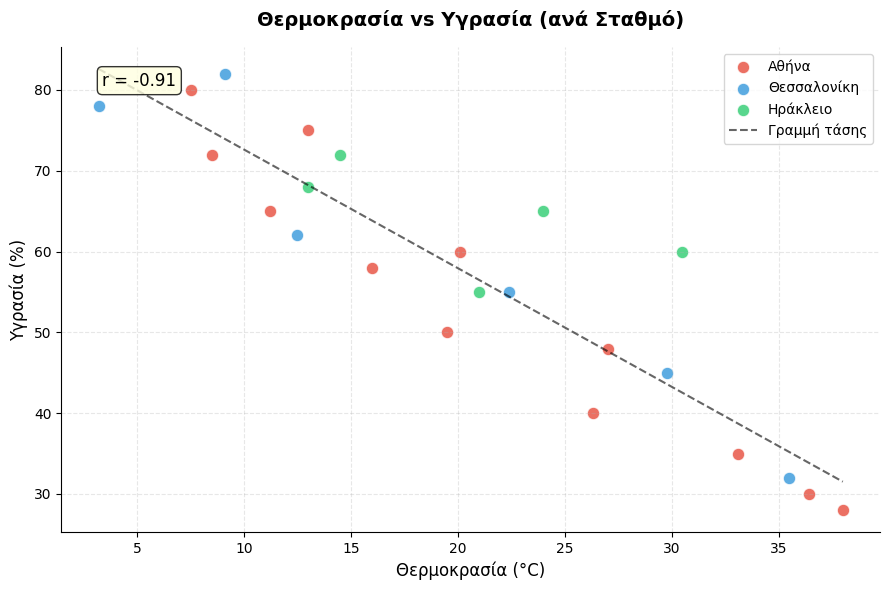

🔵 Scatter plot εμφανίστηκε. Pearson r = -0.91
   → Ισχυρή αρνητική συσχέτιση: υψηλή θερμοκρασία = χαμηλή υγρασία.


In [ ]:
### Κλήση της συνάρτησης για εμφάνιση του scatter plot

plot_temp_vs_humidity(df_all)

---
## Βήμα 4 — Ταξινόμηση Μετρήσεων

Η ταξινόμηση επιτρέπει γρήγορη εύρεση:
- Ποιες είναι οι πιο πρόσφατες μετρήσεις;
- Πού καταγράφηκαν οι υψηλότερες θερμοκρασίες;
- Πώς ομαδοποιούνται οι σταθμοί;

Χρησιμοποιούμε την `sort_values()` της pandas με παράμετρο `ascending`
που ελέγχει αν θέλουμε αύξουσα (True) ή φθίνουσα (False) σειρά.

In [ ]:
# ════════════════════════════════════════════════
# ΤΑΞΙΝΟΜΗΣΗ ΜΕΤΡΗΣΕΩΝ
# ════════════════════════════════════════════════

def sort_measurements(df, by='Ημερομηνία', ascending=True):
    """
    Ταξινόμηση του DataFrame κατά οποιαδήποτε στήλη.
    
    Παράμετροι:
        df        : pandas DataFrame
        by        : str — Όνομα στήλης για ταξινόμηση
                    ('Ημερομηνία', 'Θερμοκρασία (°C)', 'Σταθμός', κ.λπ.)
        ascending : bool — True=αύξουσα, False=φθίνουσα
    
    Επιστρέφει:
        Νέο ταξινομημένο DataFrame (δεν αλλάζει το original)
    """
    valid_cols = df.columns.tolist()
    if by not in valid_cols:
        print(f'❌ Άγνωστη στήλη: "{by}". Διαθέσιμες: {valid_cols}')
        return df

    sorted_df = df.sort_values(by=by, ascending=ascending)
    order_str = 'Αύξουσα ↑' if ascending else 'Φθίνουσα ↓'
    print(f'📋 Ταξινόμηση κατά "{by}" — {order_str}')
    return sorted_df


# ── Ταξινόμηση κατά ημερομηνία (αύξουσα — χρονολογική σειρά) ──
print('=== Κατά Ημερομηνία ===')
sort_measurements(df_all, by='Ημερομηνία', ascending=True)

=== Κατά Ημερομηνία ===
📋 Ταξινόμηση κατά "Ημερομηνία" — Αύξουσα ↑


,Σταθμός,Ημερομηνία,Θερμοκρασία (°C),Υγρασία (%),Ταχύτητα ανέμου (km/h),Καιρικές συνθήκες
ΑΘΉ_2024-01-10,Αθήνα,2024-01-10,8.5,72,15,Συννεφιά
ΗΡΆ_2024-01-10,Ηράκλειο,2024-01-10,13.0,68,22,Αίθριος
ΘΕΣ_2024-01-10,Θεσσαλονίκη,2024-01-10,3.2,78,20,Χιόνι
ΑΘΉ_2024-02-14,Αθήνα,2024-02-14,11.2,65,20,Ηλιοφάνεια
ΑΘΉ_2024-03-20,Αθήνα,2024-03-20,16.0,58,10,Ηλιοφάνεια
ΘΕΣ_2024-03-20,Θεσσαλονίκη,2024-03-20,12.5,62,18,Συννεφιά
ΑΘΉ_2024-04-05,Αθήνα,2024-04-05,19.5,50,25,Ηλιοφάνεια
ΗΡΆ_2024-04-05,Ηράκλειο,2024-04-05,21.0,55,20,Ηλιοφάνεια
ΑΘΉ_2024-05-18,Αθήνα,2024-05-18,26.3,40,18,Ηλιοφάνεια
ΑΘΉ_2024-06-22,Αθήνα,2024-06-22,33.1,35,12,Καύσωνας


In [ ]:
# ── Ταξινόμηση κατά θερμοκρασία (φθίνουσα — από τη ζεστότερη) ──
print('=== Κατά Θερμοκρασία (υψηλότερη πρώτα) ===')
sort_measurements(df_all, by='Θερμοκρασία (°C)', ascending=False)

=== Κατά Θερμοκρασία (υψηλότερη πρώτα) ===
📋 Ταξινόμηση κατά "Θερμοκρασία (°C)" — Φθίνουσα ↓


,Σταθμός,Ημερομηνία,Θερμοκρασία (°C),Υγρασία (%),Ταχύτητα ανέμου (km/h),Καιρικές συνθήκες
ΑΘΉ_2024-07-15,Αθήνα,2024-07-15,38.0,28,8,Καύσωνας
ΑΘΉ_2024-08-10,Αθήνα,2024-08-10,36.4,30,10,Καύσωνας
ΘΕΣ_2024-07-15,Θεσσαλονίκη,2024-07-15,35.5,32,10,Καύσωνας
ΑΘΉ_2024-06-22,Αθήνα,2024-06-22,33.1,35,12,Καύσωνας
ΗΡΆ_2024-07-15,Ηράκλειο,2024-07-15,30.5,60,15,Ηλιοφάνεια
ΘΕΣ_2024-06-22,Θεσσαλονίκη,2024-06-22,29.8,45,15,Ηλιοφάνεια
ΑΘΉ_2024-09-25,Αθήνα,2024-09-25,27.0,48,20,Αίθριος
ΑΘΉ_2024-05-18,Αθήνα,2024-05-18,26.3,40,18,Ηλιοφάνεια
ΗΡΆ_2024-10-08,Ηράκλειο,2024-10-08,24.0,65,18,Αίθριος
ΘΕΣ_2024-09-25,Θεσσαλονίκη,2024-09-25,22.4,55,25,Αίθριος


In [ ]:
# ── Ταξινόμηση κατά σταθμό (αλφαβητική) ──
print('=== Κατά Σταθμό (αλφαβητικά) ===')
sort_measurements(df_all, by='Σταθμός', ascending=True)

=== Κατά Σταθμό (αλφαβητικά) ===
📋 Ταξινόμηση κατά "Σταθμός" — Αύξουσα ↑


,Σταθμός,Ημερομηνία,Θερμοκρασία (°C),Υγρασία (%),Ταχύτητα ανέμου (km/h),Καιρικές συνθήκες
ΑΘΉ_2024-01-10,Αθήνα,2024-01-10,8.5,72,15,Συννεφιά
ΑΘΉ_2024-11-12,Αθήνα,2024-11-12,13.0,75,30,Βροχή
ΑΘΉ_2024-10-08,Αθήνα,2024-10-08,20.1,60,22,Συννεφιά
ΑΘΉ_2024-09-25,Αθήνα,2024-09-25,27.0,48,20,Αίθριος
ΑΘΉ_2024-08-10,Αθήνα,2024-08-10,36.4,30,10,Καύσωνας
ΑΘΉ_2024-07-15,Αθήνα,2024-07-15,38.0,28,8,Καύσωνας
ΑΘΉ_2024-12-20,Αθήνα,2024-12-20,7.5,80,35,Βροχή
ΑΘΉ_2024-05-18,Αθήνα,2024-05-18,26.3,40,18,Ηλιοφάνεια
ΑΘΉ_2024-04-05,Αθήνα,2024-04-05,19.5,50,25,Ηλιοφάνεια
ΑΘΉ_2024-03-20,Αθήνα,2024-03-20,16.0,58,10,Ηλιοφάνεια


---
## Βήμα 5 — Εντοπισμός Ακραίων Τιμών (Outliers) με IQR

### Τι είναι το IQR;

Το **IQR (Interquartile Range)** είναι η διαφορά μεταξύ του **3ου τεταρτημορίου (Q3)**
και του **1ου τεταρτημορίου (Q1)** της κατανομής:

$$IQR = Q3 - Q1$$

Μια τιμή θεωρείται **outlier** αν βρίσκεται:
- Κάτω από: $Q1 - 1.5 \times IQR$ (κάτω fence)
- Πάνω από: $Q3 + 1.5 \times IQR$ (πάνω fence)

Η μέθοδος IQR είναι **ανθεκτική** σε ακραίες τιμές (robust), σε αντίθεση
με μεθόδους που χρησιμοποιούν μέση τιμή ± n×std, επειδή δεν επηρεάζεται
από τα ίδια τα outliers.

In [ ]:
# ════════════════════════════════════════════════
# ΕΝΤΟΠΙΣΜΟΣ OUTLIERS ΜΕ IQR (numpy)
# ════════════════════════════════════════════════

def detect_outliers_iqr(df, column):
    """
    Εντοπίζει ακραίες τιμές σε μια αριθμητική στήλη χρησιμοποιώντας τη μέθοδο IQR.
    
    Αλγόριθμος:
        1. Υπολογισμός Q1 (25ο percentile) και Q3 (75ο percentile) με numpy
        2. IQR = Q3 - Q1
        3. Όρια: lower = Q1 - 1.5*IQR  ,  upper = Q3 + 1.5*IQR
        4. Outliers: τιμές εκτός [lower, upper]
    
    Παράμετροι:
        df     : pandas DataFrame
        column : str — Όνομα αριθμητικής στήλης
    
    Επιστρέφει:
        DataFrame με μόνο τις γραμμές που είναι outliers
    """
    values = df[column].values  # numpy array

    # Υπολογισμός τεταρτημορίων με numpy
    Q1 = np.percentile(values, 25)  # 25ο εκατοστημόριο
    Q3 = np.percentile(values, 75)  # 75ο εκατοστημόριο
    IQR = Q3 - Q1

    # Ορισμός ορίων
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    print(f'\n🔍 Ανάλυση Outliers για: "{column}"')
    print(f'   Q1 = {Q1:.2f}  |  Q3 = {Q3:.2f}  |  IQR = {IQR:.2f}')
    print(f'   Κάτω όριο (lower fence) : {lower_fence:.2f}')
    print(f'   Πάνω όριο (upper fence) : {upper_fence:.2f}')

    # Boolean mask: True για κάθε γραμμή που είναι outlier
    outlier_mask = (df[column] < lower_fence) | (df[column] > upper_fence)
    outliers = df[outlier_mask]

    if outliers.empty:
        print('   ✅ Δεν εντοπίστηκαν ακραίες τιμές.')
    else:
        print(f'   ⚠️  Εντοπίστηκαν {len(outliers)} ακραίες τιμές:')

    return outliers


# ── Εφαρμογή για Θερμοκρασία ──
outliers_temp = detect_outliers_iqr(df_all, 'Θερμοκρασία (°C)')
if not outliers_temp.empty:
    display(outliers_temp)


🔍 Ανάλυση Outliers για: "Θερμοκρασία (°C)"
   Q1 = 12.75  |  Q3 = 28.40  |  IQR = 15.65
   Κάτω όριο (lower fence) : -10.72
   Πάνω όριο (upper fence) : 51.88
   ✅ Δεν εντοπίστηκαν ακραίες τιμές.


In [ ]:
# ── Εφαρμογή για Υγρασία ──
outliers_hum = detect_outliers_iqr(df_all, 'Υγρασία (%)')
if not outliers_hum.empty:
    display(outliers_hum)

# ── Εφαρμογή για Ταχύτητα ανέμου ──
outliers_wind = detect_outliers_iqr(df_all, 'Ταχύτητα ανέμου (km/h)')
if not outliers_wind.empty:
    display(outliers_wind)


🔍 Ανάλυση Outliers για: "Υγρασία (%)"
   Q1 = 46.50  |  Q3 = 70.00  |  IQR = 23.50
   Κάτω όριο (lower fence) : 11.25
   Πάνω όριο (upper fence) : 105.25
   ✅ Δεν εντοπίστηκαν ακραίες τιμές.

🔍 Ανάλυση Outliers για: "Ταχύτητα ανέμου (km/h)"
   Q1 = 15.00  |  Q3 = 23.50  |  IQR = 8.50
   Κάτω όριο (lower fence) : 2.25
   Πάνω όριο (upper fence) : 36.25
   ✅ Δεν εντοπίστηκαν ακραίες τιμές.


C:\Users\xaris\AppData\Local\Temp\ipykernel_22316\3356265024.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_station,
C:\Users\xaris\AppData\Local\Temp\ipykernel_22316\3356265024.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_station,
C:\Users\xaris\AppData\Local\Temp\ipykernel_22316\3356265024.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_station,
C:\Users\xaris\AppData\Local\Temp\ipykernel_22316\3356265024.py:45: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\xar

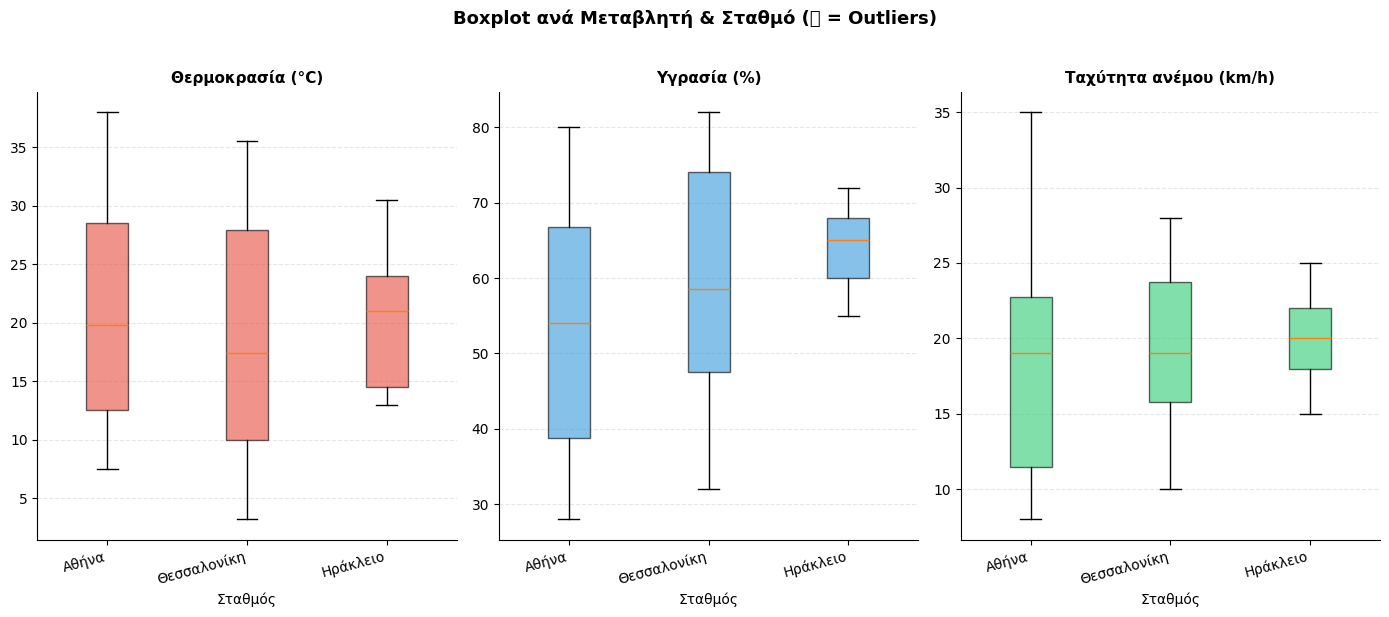

📦 Boxplot εμφανίστηκε.


In [ ]:
# ════════════════════════════════════════════════
# ΟΠΤΙΚΟΠΟΙΗΣΗ OUTLIERS — Boxplot
# ════════════════════════════════════════════════
# Το boxplot είναι το κατεξοχήν γράφημα για IQR outliers:
# - Το κουτί = Q1 έως Q3 (IQR)
# - Η κεντρική γραμμή = διάμεσος (Q2)
# - Τα «μουστάκια» (whiskers) = fences
# - Οι τελείες έξω από τα μουστάκια = outliers

def plot_outliers_boxplot(df):
    """
    Boxplot για τις τρεις κύριες αριθμητικές μεταβλητές,
    με χρωματισμό ανά σταθμό.
    """
    numeric_cols = ['Θερμοκρασία (°C)', 'Υγρασία (%)', 'Ταχύτητα ανέμου (km/h)']
    fig, axes = plt.subplots(1, 3, figsize=(14, 6))

    palette = ['#e74c3c', '#3498db', '#2ecc71']
    stations = df['Σταθμός'].unique()

    for ax, col, color in zip(axes, numeric_cols, palette):
        # Δεδομένα ανά σταθμό για grouped boxplot
        data_by_station = [df[df['Σταθμός'] == st][col].values for st in stations]

        bp = ax.boxplot(data_by_station,
                        labels=stations,
                        patch_artist=True,   # Γεμιστά κουτιά
                        notch=False,
                        flierprops=dict(marker='o', color='red',  # Outliers κόκκινα
                                        markersize=8, markerfacecolor='red'))

        # Χρωματισμός κουτιών
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.6)

        ax.set_title(col, fontsize=11, fontweight='bold')
        ax.set_xlabel('Σταθμός', fontsize=10)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.spines[['top', 'right']].set_visible(False)
        plt.setp(ax.get_xticklabels(), rotation=15, ha='right')

    fig.suptitle('Boxplot ανά Μεταβλητή & Σταθμό (🔴 = Outliers)', 
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    print('📦 Boxplot εμφανίστηκε.')


plot_outliers_boxplot(df_all)

# 3ο Στάδιο — Έξυπνη Ανάλυση

---

Το τελευταίο στάδιο επεκτείνει το σύστημα με τρεις έξυπνες δυνατότητες:

| Λειτουργία | Μέθοδος | Σκοπός |
|---|---|---|
| **Συσχέτιση μεταβλητών** | `DataFrame.corr()` + Pearson | Ποιες μεταβλητές συνδέονται μεταξύ τους; |
| **Πρόβλεψη τάσης** | `numpy.polyfit()` γραμμική παλινδρόμηση | Πού κατευθύνεται η θερμοκρασία; |
| **Έξυπνη αναζήτηση** | Fuzzy string matching (`thefuzz`) | Τι εννοούσε ο χρήστης όταν έγραψε λάθος; |

---
## Βήμα 1 — Συσχέτιση Μεταβλητών (Pearson Correlation Matrix)

### Τι είναι ο συντελεστής Pearson;

Ο **συντελεστής συσχέτισης Pearson** $r$ μετρά τη **γραμμική σχέση** μεταξύ δύο αριθμητικών μεταβλητών:

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \cdot \sum (y_i - \bar{y})^2}}$$

| Τιμή $r$ | Ερμηνεία |
|---|---|
| $r \approx +1$ | Ισχυρή θετική συσχέτιση |
| $r \approx -1$ | Ισχυρή αρνητική συσχέτιση |
| $r \approx 0$ | Απουσία γραμμικής συσχέτισης |

Η `DataFrame.corr()` υπολογίζει **όλα τα ζεύγη** μεταβλητών ταυτόχρονα και επιστρέφει έναν πίνακα συσχέτισης.

In [ ]:
# ════════════════════════════════════════════════
# ΒΗΜΑ 1: ΣΥΣΧΕΤΙΣΗ ΜΕΤΑΒΛΗΤΩΝ
# ════════════════════════════════════════════════

def compute_correlation(df):
    """
    Υπολογίζει τον πίνακα συσχέτισης Pearson για τις
    τρεις αριθμητικές μεταβλητές: Θερμοκρασία, Υγρασία, Ταχύτητα Ανέμου.

    Η DataFrame.corr() υπολογίζει τον συντελεστή Pearson r για
    κάθε ζεύγος στηλών. Ο διαγώνιος έχει πάντα 1.0 (τέλεια αυτοσυσχέτιση).

    Παράμετρος:
        df : pandas DataFrame με τις μετρήσεις
    Επιστρέφει:
        corr_matrix : pandas DataFrame — ο πίνακας συσχέτισης
    """
    # Επιλογή μόνο των αριθμητικών στηλών που μας ενδιαφέρουν
    numeric_cols = ["Θερμοκρασία (°C)", "Υγρασία (%)", "Ταχύτητα ανέμου (km/h)"]
    df_numeric = df[numeric_cols]

    # Υπολογισμός πίνακα συσχέτισης Pearson
    # method="pearson" είναι η προεπιλογή — το αναφέρουμε ρητά για σαφήνεια
    corr_matrix = df_numeric.corr(method="pearson")

    print("\n📊 --- Πίνακας Συσχέτισης Pearson ---")
    print(corr_matrix.round(3))

    # ── Ερμηνεία αποτελεσμάτων ──
    # Εξάγουμε τα ζεύγη (χωρίς τον διαγώνιο και τα διπλά)
    print("\n🔎 Ερμηνεία:")
    for i in range(len(numeric_cols)):
        for j in range(i + 1, len(numeric_cols)):  # j > i αποφεύγει τα διπλά
            r = corr_matrix.iloc[i, j]  # Τιμή r για το ζεύγος i,j
            col_a = numeric_cols[i]
            col_b = numeric_cols[j]

            # Κατηγοριοποίηση ισχύος συσχέτισης βάσει απόλυτης τιμής
            if abs(r) >= 0.7:
                strength = "Ισχυρή"
            elif abs(r) >= 0.4:
                strength = "Μέτρια"
            else:
                strength = "Ασθενής / Καμία"

            direction = "θετική" if r > 0 else "αρνητική"
            print(f"  • {col_a} ↔ {col_b}: r = {r:.3f} ({strength} {direction} συσχέτιση)")

    return corr_matrix


# Εκτέλεση υπολογισμού συσχέτισης
corr_matrix = compute_correlation(df_all)



📊 --- Πίνακας Συσχέτισης Pearson ---
                        Θερμοκρασία (°C)  Υγρασία (%)  Ταχύτητα ανέμου (km/h)
Θερμοκρασία (°C)                   1.000       -0.912                  -0.656
Υγρασία (%)                       -0.912        1.000                   0.721
Ταχύτητα ανέμου (km/h)            -0.656        0.721                   1.000

🔎 Ερμηνεία:
  • Θερμοκρασία (°C) ↔ Υγρασία (%): r = -0.912 (Ισχυρή αρνητική συσχέτιση)
  • Θερμοκρασία (°C) ↔ Ταχύτητα ανέμου (km/h): r = -0.656 (Μέτρια αρνητική συσχέτιση)
  • Υγρασία (%) ↔ Ταχύτητα ανέμου (km/h): r = 0.721 (Ισχυρή θετική συσχέτιση)


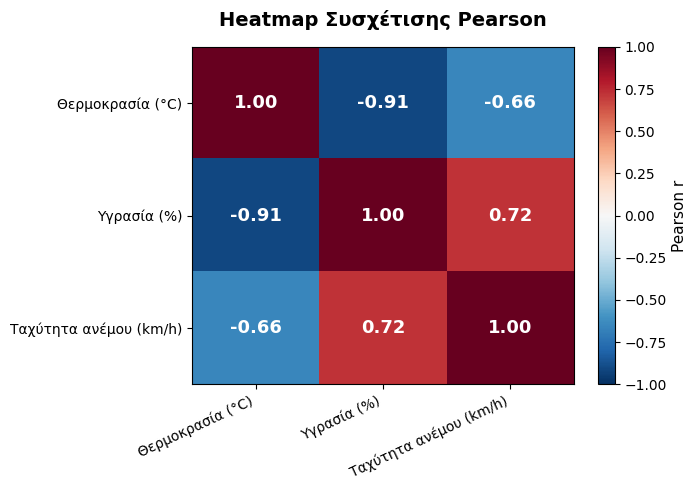

🌡️  Heatmap εμφανίστηκε.


In [ ]:
# ════════════════════════════════════════════════
# ΟΠΤΙΚΟΠΟΙΗΣΗ: HEATMAP ΣΥΣΧΕΤΙΣΗΣ
# ════════════════════════════════════════════════
# Το heatmap μετατρέπει τον αριθμητικό πίνακα σε
# χρωματικό χάρτη: κόκκινο = θετική, μπλε = αρνητική.
# Είναι η πιο διαδεδομένη οπτικοποίηση πινάκων συσχέτισης.

def plot_correlation_heatmap(corr_matrix):
    """
    Απεικονίζει τον πίνακα συσχέτισης ως heatmap.

    Κάθε κελί χρωματίζεται με βάση την τιμή r:
      - Κόκκινο  → θετική συσχέτιση
      - Μπλε     → αρνητική συσχέτιση
      - Λευκό    → r ≈ 0

    Παράμετρος:
        corr_matrix : pandas DataFrame — πίνακας συσχέτισης
    """
    fig, ax = plt.subplots(figsize=(7, 5))

    labels = corr_matrix.columns.tolist()
    data   = corr_matrix.values  # numpy array από τον DataFrame

    # imshow: εμφανίζει 2D πίνακα ως εικόνα χρώματος
    # vmin/vmax: κλίμακα [-1, 1] για ομαλή χρωματική απεικόνιση
    im = ax.imshow(data, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

    # Colorbar: εξηγεί την κλίμακα χρωμάτων
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Pearson r", fontsize=11)

    # Ετικέτες αξόνων — ίδιες για X και Y (συμμετρικός πίνακας)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=10)
    ax.set_yticklabels(labels, fontsize=10)

    # Εγγραφή τιμής r μέσα σε κάθε κελί
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = data[i, j]
            # Λευκό κείμενο σε σκούρο φόντο, μαύρο σε ανοιχτό
            text_color = "white" if abs(val) > 0.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=13, fontweight="bold", color=text_color)

    ax.set_title("Heatmap Συσχέτισης Pearson", fontsize=14,
                 fontweight="bold", pad=15)
    plt.tight_layout()
    plt.show()
    print("🌡️  Heatmap εμφανίστηκε.")


plot_correlation_heatmap(corr_matrix)


---
## Βήμα 2 — Πρόβλεψη Τάσης με Γραμμική Παλινδρόμηση (`numpy.polyfit`)

### Τι είναι η γραμμική παλινδρόμηση;

Η **γραμμική παλινδρόμηση** βρίσκει την ευθεία $y = ax + b$ που ελαχιστοποιεί
το άθροισμα τετραγώνων αποκλίσεων (least squares) από τα πραγματικά δεδομένα.

Η `numpy.polyfit(x, y, deg=1)` επιστρέφει τους συντελεστές $[a, b]$ της ευθείας,
ενώ η `numpy.polyval([a, b], x)` υπολογίζει τις προβλεπόμενες τιμές.

> **Ερμηνεία:** Αν $a > 0$ η τάση είναι **ανοδική**, αν $a < 0$ είναι **καθοδική**.

**Σημείωση:** Μετατρέπουμε τις ημερομηνίες σε αριθμητικές τιμές με `toordinal()`
(αριθμός ημερών από αρχαία βάση αναφοράς), ώστε να μπορεί να τις επεξεργαστεί η `polyfit`.

C:\Users\xaris\AppData\Local\Temp\ipykernel_22316\1845116688.py:65: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\xaris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


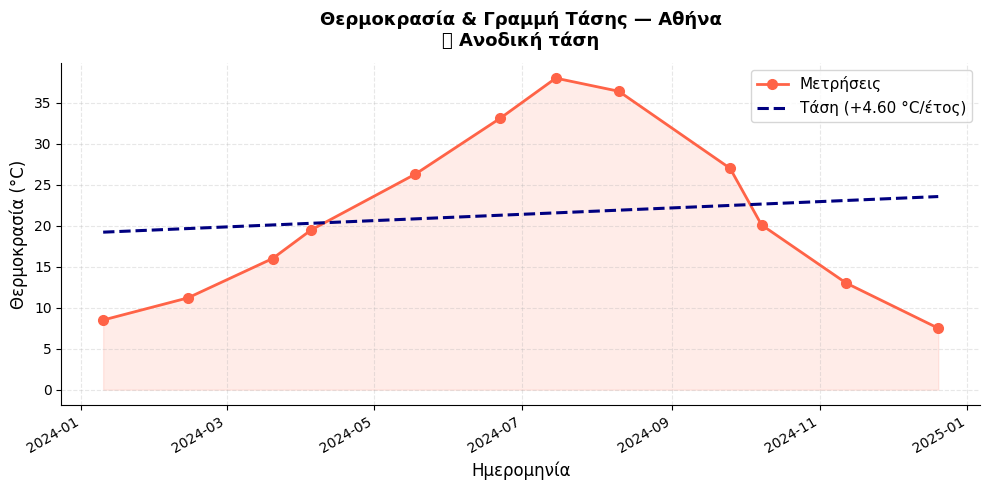


📐 Αποτελέσματα Παλινδρόμησης για "Αθήνα":
   Κλίση (a)    : 0.012592 °C/ημέρα  →  4.596 °C/έτος
   Σταθερός (b) : -9284.886
   → Η θερμοκρασία αυξάνεται κατά 4.60°C ανά έτος.


In [ ]:
# ════════════════════════════════════════════════
# ΒΗΜΑ 2: ΓΡΑΜΜΙΚΗ ΠΑΛΙΝΔΡΟΜΗΣΗ & ΤΑΣH ΘΕΡΜΟΚΡΑΣΙΑΣ
# ════════════════════════════════════════════════

def plot_temperature_trend(df, station_name):
    """
    Σχεδιάζει τη χρονοσειρά θερμοκρασίας για έναν σταθμό
    μαζί με τη γραμμή τάσης (trend line) από γραμμική παλινδρόμηση.

    Βήματα:
        1. Φιλτράρει τον σταθμό και ταξινομεί κατά ημερομηνία.
        2. Μετατρέπει ημερομηνίες → ordinal integers (αριθμοί ημερών)
           για να μπορεί να τα δεχτεί η numpy.polyfit.
        3. polyfit(x, y, 1) → συντελεστές [a, b] της ευθείας y = ax + b
        4. polyval([a, b], x) → υπολογισμός trend line
        5. Σχεδιάζει πραγματικές μετρήσεις + trend line στο ίδιο γράφημα.

    Παράμετροι:
        df           : pandas DataFrame
        station_name : str — Όνομα σταθμού
    """
    # Φιλτράρισμα & ταξινόμηση
    df_s = df[df["Σταθμός"] == station_name].copy()
    if df_s.empty:
        print(f"⚠️  Δεν βρέθηκαν δεδομένα για τον σταθμό: {station_name}")
        return

    df_s["Ημερομηνία"] = pd.to_datetime(df_s["Ημερομηνία"])
    df_s = df_s.sort_values("Ημερομηνία")

    # Μετατροπή ημερομηνιών σε ακέραιους (ordinal) — απαραίτητο για polyfit
    x_ordinal = np.array([d.toordinal() for d in df_s["Ημερομηνία"]])
    y_temp    = df_s["Θερμοκρασία (°C)"].values

    # ── Γραμμική Παλινδρόμηση ──
    # deg=1: πολυώνυμο 1ου βαθμού (ευθεία)  y = a*x + b
    coeffs     = np.polyfit(x_ordinal, y_temp, deg=1)
    a, b       = coeffs          # a=κλίση, b=σταθερός όρος
    trend_vals = np.polyval(coeffs, x_ordinal)  # Τιμές trend line

    # ── Γράφημα ──
    fig, ax = plt.subplots(figsize=(10, 5))

    # Πραγματικές μετρήσεις
    ax.plot(df_s["Ημερομηνία"], y_temp,
            marker="o", linewidth=2, color="tomato",
            markersize=7, label="Μετρήσεις")
    ax.fill_between(df_s["Ημερομηνία"], y_temp, alpha=0.12, color="tomato")

    # Trend line με διακεκομμένη γραμμή — ξεχωρίζει από τις μετρήσεις
    # Μετατρέπουμε a από °C/ημέρα → °C/έτος (×365) για ευανάγνωστη μονάδα
    ax.plot(df_s["Ημερομηνία"], trend_vals,
            linestyle="--", linewidth=2.2, color="navy",
            label=f"Τάση ({a*365:+.2f} °C/έτος)")

    trend_msg = "📈 Ανοδική τάση" if a > 0 else "📉 Καθοδική τάση"
    ax.set_title(f"Θερμοκρασία & Γραμμή Τάσης — {station_name}\n{trend_msg}",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Ημερομηνία", fontsize=12)
    ax.set_ylabel("Θερμοκρασία (°C)", fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    # ── Εκτύπωση αποτελεσμάτων παλινδρόμησης ──
    print(f"\n📐 Αποτελέσματα Παλινδρόμησης για \"{station_name}\":" )
    print(f"   Κλίση (a)    : {a:.6f} °C/ημέρα  →  {a*365:.3f} °C/έτος")
    print(f"   Σταθερός (b) : {b:.3f}")
    if a > 0:
        print(f"   → Η θερμοκρασία αυξάνεται κατά {a*365:.2f}°C ανά έτος.")
    else:
        print(f"   → Η θερμοκρασία μειώνεται κατά {abs(a)*365:.2f}°C ανά έτος.")


# Εφαρμογή για τον σταθμό Αθήνας (12 σημεία — ιδανικό για τάση)
plot_temperature_trend(df_all, "Αθήνα")


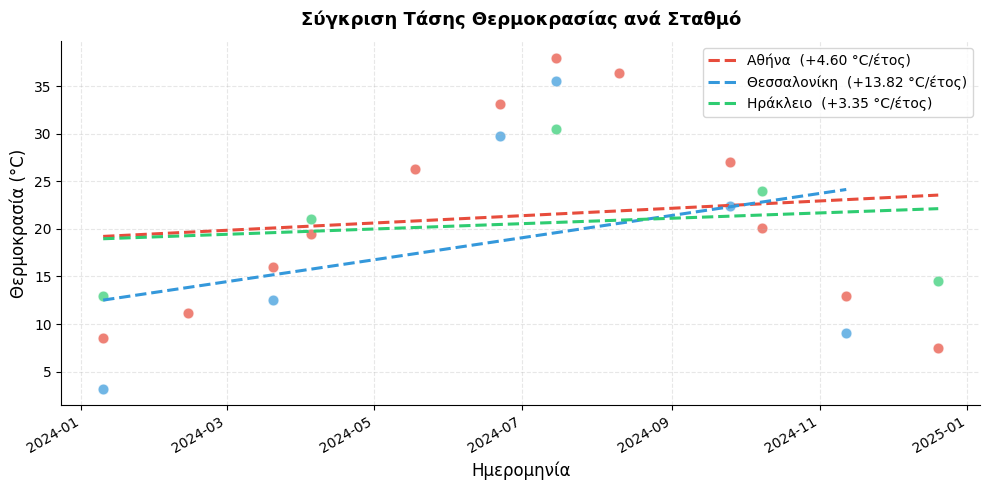

📈 Σύγκριση τάσεων όλων των σταθμών εμφανίστηκε.


In [ ]:
# ════════════════════════════════════════════════
# ΣΥΓΚΡΙΣΗ ΤΑΣΕΩΝ ΟΛΩΝ ΤΩΝ ΣΤΑΘΜΩΝ
# ════════════════════════════════════════════════
# Εφαρμόζουμε τη γραμμική παλινδρόμηση σε κάθε σταθμό ξεχωριστά
# και συγκρίνουμε τις κλίσεις τους στο ίδιο γράφημα.

fig, ax = plt.subplots(figsize=(10, 5))

palette  = ["#e74c3c", "#3498db", "#2ecc71"]
stations = df_all["Σταθμός"].unique()

for color, station in zip(palette, stations):
    df_s = df_all[df_all["Σταθμός"] == station].copy()
    df_s["Ημερομηνία"] = pd.to_datetime(df_s["Ημερομηνία"])
    df_s = df_s.sort_values("Ημερομηνία")

    # Μετατροπή σε ordinal για polyfit
    x_ord = np.array([d.toordinal() for d in df_s["Ημερομηνία"]])
    y_t   = df_s["Θερμοκρασία (°C)"].values

    # Σημεία μετρήσεων
    ax.scatter(df_s["Ημερομηνία"], y_t, color=color, s=60,
               alpha=0.7, edgecolors="white", linewidth=0.6)

    # Γραμμή τάσης ανά σταθμό
    coeffs = np.polyfit(x_ord, y_t, deg=1)
    trend  = np.polyval(coeffs, x_ord)
    rate   = coeffs[0] * 365  # °C/έτος
    ax.plot(df_s["Ημερομηνία"], trend,
            color=color, linewidth=2.2, linestyle="--",
            label=f"{station}  ({rate:+.2f} °C/έτος)")

ax.set_title("Σύγκριση Τάσης Θερμοκρασίας ανά Σταθμό",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Ημερομηνία", fontsize=12)
ax.set_ylabel("Θερμοκρασία (°C)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
print("📈 Σύγκριση τάσεων όλων των σταθμών εμφανίστηκε.")


---
## Βήμα 3 — Έξυπνη Αναζήτηση με Fuzzy String Matching

### Το πρόβλημα

Όταν ο χρήστης πληκτρολογεί `"Αθηνα"` (χωρίς τόνο) ή `"Θεσαλονικη"` (τυπογραφικό λάθος),
η κλασική αναζήτηση με `==` αποτυγχάνει.

### Η λύση: `thefuzz` + απόσταση Levenshtein

Η βιβλιοθήκη `thefuzz` μετρά πόσες αλλαγές χαρακτήρων χρειάζονται
για να μετατραπεί μια λέξη σε μια άλλη (**απόσταση Levenshtein**)
και επιστρέφει ένα **score ομοιότητας 0–100**.

```
fuzz.ratio("Αθηνα", "Αθήνα")      → ~90
fuzz.ratio("Θεσαλονικη", "Θεσσαλονίκη") → ~82
fuzz.ratio("Πάτρα",  "Αθήνα")     → ~30
```

Χρησιμοποιούμε `process.extractBests()` για να βρούμε **όλες**
τις κοντινές αντιστοιχίσεις πάνω από ένα `threshold` (κατώφλι ομοιότητας).

In [ ]:
# Εγκατάσταση thefuzz (αν δεν υπάρχει ήδη)
# python-Levenshtein: C-extension για ταχύτερη εκτέλεση (προαιρετικό)
!pip install thefuzz python-Levenshtein -q

from thefuzz import fuzz, process

print("✅ Βιβλιοθήκη thefuzz φορτώθηκε επιτυχώς.")



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\xaris\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


✅ Βιβλιοθήκη thefuzz φορτώθηκε επιτυχώς.


In [ ]:
# ════════════════════════════════════════════════
# ΕΞΥΠΝΗ ΑΝΑΖΗΤΗΣΗ: smart_search_station()
# ════════════════════════════════════════════════

def smart_search_station(query, df, threshold=60):
    """
    Αναζήτηση μετρήσεων σταθμού με fuzzy string matching.

    Αλγόριθμος:
        1. Παίρνει τη λίστα μοναδικών σταθμών από το DataFrame.
        2. process.extractBests() βρίσκει όλες τις αντιστοιχίσεις
           με score >= threshold (0-100 κλίμακα ομοιότητας).
        3. Αν βρεθεί ακριβής αντιστοίχιση (score=100) → επιστρέφει αποτελέσματα.
        4. Αν βρεθούν κοντινές αντιστοιχίσεις → προτείνει τις επιλογές
           και επιλέγει αυτόματα την πρώτη (καλύτερη).
        5. Αν δεν βρεθεί τίποτα → εμφανίζει διαθέσιμους σταθμούς.

    Παράμετροι:
        query     : str — Το ερώτημα (μπορεί να έχει λάθη)
        df        : pandas DataFrame με τα δεδομένα
        threshold : int — Ελάχιστο score (0-100, default 60)

    Επιστρέφει:
        pandas DataFrame ή None αν δεν βρεθεί τίποτα
    """
    available_stations = df["Σταθμός"].unique().tolist()

    # process.extractBests: επιστρέφει λίστα (σταθμός, score)
    # scorer=token_sort_ratio: ανθεκτικό σε αλλαγές σειράς λέξεων
    matches = process.extractBests(
        query,
        available_stations,
        scorer=fuzz.token_sort_ratio,
        score_cutoff=threshold
    )

    # ── Κανένα αποτέλεσμα ──
    if not matches:
        print(f"❌ Δεν βρέθηκε σταθμός για \"{query}\".")
        print(f"   Διαθέσιμοι σταθμοί: {chr(44)+chr(32).join(available_stations)}")
        return None

    best_match, best_score = matches[0]

    # ── Ακριβής αντιστοίχιση ──
    if best_score == 100:
        result = df[df["Σταθμός"] == best_match]
        print(f"✅ Ακριβής αντιστοίχιση: \"{best_match}\" — {len(result)} εγγραφές")
        return result

    # ── Ασαφής αντιστοίχιση: προτείνουμε εναλλακτικές ──
    print(f"⚠️  Ο σταθμός \"{query}\" δεν βρέθηκε ακριβώς.")
    print(f"   Εννοούσατε κάποιον από τους παρακάτω;")
    for i, (station, score) in enumerate(matches):
        print(f"   [{i+1}] {station}  (ομοιότητα: {score}%)")

    # Αυτόματη επιλογή της καλύτερης πρότασης (υψηλότερο score)
    print(f"\n   → Αυτόματη επιλογή: \"{best_match}\" ({best_score}%)")
    return df[df["Σταθμός"] == best_match]


print("✅ Συνάρτηση smart_search_station() ορίστηκε.")


✅ Συνάρτηση smart_search_station() ορίστηκε.


In [ ]:
# ════════════════════════════════════════════════
# ΕΠΙΔΕΙΞΗ ΕΞΥΠΝΗΣ ΑΝΑΖΗΤΗΣΗΣ — 4 Σενάρια
# ════════════════════════════════════════════════
# Δοκιμάζουμε τέσσερις περιπτώσεις που καλύπτουν
# τα κυριότερα είδη λάθους πληκτρολόγησης:

test_queries = [
    ("Αθηνα",        "Χωρίς τόνο"),
    ("Θεσαλονικη",   "Τυπογραφικό λάθος"),
    ("Ηρακλ",        "Μερική λέξη"),
    ("Πάτρα",        "Ανύπαρκτος σταθμός"),
]

for query, description in test_queries:
    sep = "=" * 55
    print(f"\n{sep}")
    print(f"🔎 Ερώτημα: \"{query}\"  —  {description}")
    print("="*55)
    result = smart_search_station(query, df_all)
    if result is not None and not result.empty:
        display(result[["Σταθμός", "Ημερομηνία", "Θερμοκρασία (°C)",
                         "Υγρασία (%)", "Καιρικές συνθήκες"]])



🔎 Ερώτημα: "Αθηνα"  —  Χωρίς τόνο
⚠️  Ο σταθμός "Αθηνα" δεν βρέθηκε ακριβώς.
   Εννοούσατε κάποιον από τους παρακάτω;
   [1] Αθήνα  (ομοιότητα: 80%)

   → Αυτόματη επιλογή: "Αθήνα" (80%)


,Σταθμός,Ημερομηνία,Θερμοκρασία (°C),Υγρασία (%),Καιρικές συνθήκες
ΑΘΉ_2024-01-10,Αθήνα,2024-01-10,8.5,72,Συννεφιά
ΑΘΉ_2024-02-14,Αθήνα,2024-02-14,11.2,65,Ηλιοφάνεια
ΑΘΉ_2024-03-20,Αθήνα,2024-03-20,16.0,58,Ηλιοφάνεια
ΑΘΉ_2024-04-05,Αθήνα,2024-04-05,19.5,50,Ηλιοφάνεια
ΑΘΉ_2024-05-18,Αθήνα,2024-05-18,26.3,40,Ηλιοφάνεια
ΑΘΉ_2024-06-22,Αθήνα,2024-06-22,33.1,35,Καύσωνας
ΑΘΉ_2024-07-15,Αθήνα,2024-07-15,38.0,28,Καύσωνας
ΑΘΉ_2024-08-10,Αθήνα,2024-08-10,36.4,30,Καύσωνας
ΑΘΉ_2024-09-25,Αθήνα,2024-09-25,27.0,48,Αίθριος
ΑΘΉ_2024-10-08,Αθήνα,2024-10-08,20.1,60,Συννεφιά



🔎 Ερώτημα: "Θεσαλονικη"  —  Τυπογραφικό λάθος
⚠️  Ο σταθμός "Θεσαλονικη" δεν βρέθηκε ακριβώς.
   Εννοούσατε κάποιον από τους παρακάτω;
   [1] Θεσσαλονίκη  (ομοιότητα: 86%)

   → Αυτόματη επιλογή: "Θεσσαλονίκη" (86%)


,Σταθμός,Ημερομηνία,Θερμοκρασία (°C),Υγρασία (%),Καιρικές συνθήκες
ΘΕΣ_2024-01-10,Θεσσαλονίκη,2024-01-10,3.2,78,Χιόνι
ΘΕΣ_2024-03-20,Θεσσαλονίκη,2024-03-20,12.5,62,Συννεφιά
ΘΕΣ_2024-06-22,Θεσσαλονίκη,2024-06-22,29.8,45,Ηλιοφάνεια
ΘΕΣ_2024-07-15,Θεσσαλονίκη,2024-07-15,35.5,32,Καύσωνας
ΘΕΣ_2024-09-25,Θεσσαλονίκη,2024-09-25,22.4,55,Αίθριος
ΘΕΣ_2024-11-12,Θεσσαλονίκη,2024-11-12,9.1,82,Βροχή



🔎 Ερώτημα: "Ηρακλ"  —  Μερική λέξη
⚠️  Ο σταθμός "Ηρακλ" δεν βρέθηκε ακριβώς.
   Εννοούσατε κάποιον από τους παρακάτω;
   [1] Ηράκλειο  (ομοιότητα: 62%)

   → Αυτόματη επιλογή: "Ηράκλειο" (62%)


,Σταθμός,Ημερομηνία,Θερμοκρασία (°C),Υγρασία (%),Καιρικές συνθήκες
ΗΡΆ_2024-01-10,Ηράκλειο,2024-01-10,13.0,68,Αίθριος
ΗΡΆ_2024-04-05,Ηράκλειο,2024-04-05,21.0,55,Ηλιοφάνεια
ΗΡΆ_2024-07-15,Ηράκλειο,2024-07-15,30.5,60,Ηλιοφάνεια
ΗΡΆ_2024-10-08,Ηράκλειο,2024-10-08,24.0,65,Αίθριος
ΗΡΆ_2024-12-20,Ηράκλειο,2024-12-20,14.5,72,Βροχή



🔎 Ερώτημα: "Πάτρα"  —  Ανύπαρκτος σταθμός
❌ Δεν βρέθηκε σταθμός για "Πάτρα".
   Διαθέσιμοι σταθμοί: ,Αθήνα Θεσσαλονίκη Ηράκλειο


---
## Βήμα 4 — Ενσωμάτωση Fuzzy Matching στη `search_measurements()`

Αναβαθμίζουμε τη `search_measurements()` του Σταδίου 1 ώστε να
ενεργοποιεί αυτόματα το fuzzy matching όταν ο σταθμός δεν βρίσκεται ακριβώς.
Προσθέτουμε παράμετρο `fuzzy=True` για να ελέγχεται αν θέλουμε αυτή τη συμπεριφορά.

In [ ]:
# ════════════════════════════════════════════════
# ΑΝΑΒΑΘΜΙΣΗ search_measurements() ΜΕ FUZZY
# ════════════════════════════════════════════════
# Η νέα έκδοση αντικαθιστά την παλιά από το Στάδιο 1.
# Προσθέτουμε μόνο τη λογική fuzzy — δεν αλλάζουμε τίποτα άλλο.

def search_measurements(station=None, start_date=None, end_date=None, fuzzy=True):
    """
    Αναζήτηση μετρήσεων με προαιρετικό fuzzy matching.

    Νέα παράμετρος σε σχέση με το Στάδιο 1:
        fuzzy : bool — Αν True (default), ενεργοποιεί fuzzy matching
                       αν ο σταθμός δεν βρεθεί ακριβώς.

    Λογική εκτέλεσης:
        1. station=None  → επιστρέφει όλες τις εγγραφές (με φίλτρο ημερομηνιών).
        2. Ακριβής αντιστοίχιση → κανονική αναζήτηση.
        3. Δεν βρέθηκε + fuzzy=True → smart_search_station().
        4. Εφαρμόζει φίλτρο ημερομηνιών στο τελικό αποτέλεσμα.
    """
    try:
        if not weather_data:
            print("ℹ️  Δεν υπάρχουν δεδομένα.")
            return {}

        df = pd.DataFrame.from_dict(weather_data, orient="index")

        # ── Φίλτρο σταθμού ──
        if station is not None:
            available = df["Σταθμός"].unique().tolist()

            # Ελέγχουμε για ακριβή αντιστοίχιση (case-insensitive)
            exact_match = next(
                (s for s in available if s.lower() == station.lower()), None
            )

            if exact_match:
                # Βρήκαμε ακριβώς τον σταθμό — κανονικό φιλτράρισμα
                df = df[df["Σταθμός"] == exact_match]
            elif fuzzy:
                # Δεν βρέθηκε — ενεργοποιούμε fuzzy αναζήτηση
                print(f"🔍 Fuzzy αναζήτηση για \"{station}\"...")
                df = smart_search_station(station, df)
                if df is None:
                    return {}  # Καμία πρόταση δεν βρέθηκε
            else:
                # fuzzy=False — αυστηρή αναζήτηση, δεν βρέθηκε τίποτα
                print(f"ℹ️  Δεν βρέθηκε σταθμός: \"{station}\"")
                return {}

        # ── Φίλτρο ημερομηνιών ──
        if start_date and end_date:
            df = df[(df["Ημερομηνία"] >= start_date) & (df["Ημερομηνία"] <= end_date)]

        if df.empty:
            print("ℹ️  Δεν βρέθηκαν αποτελέσματα.")
            return {}

        # Επιστροφή ως λεξικό για συμβατότητα με το υπόλοιπο σύστημα
        return df.to_dict(orient="index")

    except Exception as e:
        print(f"❌ Σφάλμα κατά την αναζήτηση: {e}")
        return {}


# ── Επίδειξη αναβαθμισμένης αναζήτησης ──
print("=== Αναζήτηση με λάθος τόνο ===")
results = search_measurements(station="Θεσσαλονικη")  # χωρίς τόνο
if results:
    display(pd.DataFrame.from_dict(results, orient="index"))

print("\n=== Αναζήτηση με fuzzy=False (αυστηρή) ===")
results_strict = search_measurements(station="Θεσσαλονικη", fuzzy=False)
print(f"Αποτελέσματα (αυστηρή): {len(results_strict)} εγγραφές")


=== Αναζήτηση με λάθος τόνο ===
🔍 Fuzzy αναζήτηση για "Θεσσαλονικη"...
⚠️  Ο σταθμός "Θεσσαλονικη" δεν βρέθηκε ακριβώς.
   Εννοούσατε κάποιον από τους παρακάτω;
   [1] Θεσσαλονίκη  (ομοιότητα: 91%)

   → Αυτόματη επιλογή: "Θεσσαλονίκη" (91%)


,Σταθμός,Ημερομηνία,Θερμοκρασία (°C),Υγρασία (%),Ταχύτητα ανέμου (km/h),Καιρικές συνθήκες
ΘΕΣ_2024-01-10,Θεσσαλονίκη,2024-01-10,3.2,78,20,Χιόνι
ΘΕΣ_2024-03-20,Θεσσαλονίκη,2024-03-20,12.5,62,18,Συννεφιά
ΘΕΣ_2024-06-22,Θεσσαλονίκη,2024-06-22,29.8,45,15,Ηλιοφάνεια
ΘΕΣ_2024-07-15,Θεσσαλονίκη,2024-07-15,35.5,32,10,Καύσωνας
ΘΕΣ_2024-09-25,Θεσσαλονίκη,2024-09-25,22.4,55,25,Αίθριος
ΘΕΣ_2024-11-12,Θεσσαλονίκη,2024-11-12,9.1,82,28,Βροχή



=== Αναζήτηση με fuzzy=False (αυστηρή) ===
ℹ️  Δεν βρέθηκε σταθμός: "Θεσσαλονικη"
Αποτελέσματα (αυστηρή): 0 εγγραφές


In [ ]:
# ════════════════════════════════════════════════
# ΤΕΛΙΚΗ ΕΠΙΔΕΙΞΗ: Εκτέλεση όλης της ανάλυσης
# ════════════════════════════════════════════════
print('\n' + '='*50)
print('  ΜΕΤΕΩΡΟΛΟΓΙΚΟ ΣΥΣΤΗΜΑ — ΠΛΗΡΗΣ ΑΝΑΛΥΣΗ')
print('='*50)

print(f'\n📌 Σύνολο μετρήσεων: {len(weather_data)}')
print(f'📌 Σταθμοί: {list(df_all["Σταθμός"].unique())}')
print(f'📌 Περίοδος: {df_all["Ημερομηνία"].min()} έως {df_all["Ημερομηνία"].max()}')

print('\n📊 Στατιστικά Θερμοκρασίας ανά Σταθμό:')
print(df_all.groupby('Σταθμός')['Θερμοκρασία (°C)'].agg(['mean','max','min']).round(1))

print('\n💾 Αποθήκευση τελικών δεδομένων...')
save_to_json()
save_to_csv()

print('\n✅ Ανάλυση ολοκληρώθηκε!')


  ΜΕΤΕΩΡΟΛΟΓΙΚΟ ΣΥΣΤΗΜΑ — ΠΛΗΡΗΣ ΑΝΑΛΥΣΗ

📌 Σύνολο μετρήσεων: 23
📌 Σταθμοί: ['Αθήνα', 'Θεσσαλονίκη', 'Ηράκλειο']
📌 Περίοδος: 2024-01-10 έως 2024-12-20

📊 Στατιστικά Θερμοκρασίας ανά Σταθμό:
             mean   max   min
Σταθμός                      
Αθήνα        21.4  38.0   7.5
Ηράκλειο     20.6  30.5  13.0
Θεσσαλονίκη  18.8  35.5   3.2

💾 Αποθήκευση τελικών δεδομένων...
💾 Δεδομένα αποθηκεύτηκαν στο: weather_data.json
💾 CSV αποθηκεύτηκε: weather_data.csv (23 γραμμές)

✅ Ανάλυση ολοκληρώθηκε!
